In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [2]:
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=365, freq='D')

temperature  = np.random.uniform(18, 42, 365)
humidity     = np.random.uniform(30, 90, 365)
day_of_week  = np.array([d.dayofweek for d in dates])
month        = np.array([d.month for d in dates])
is_weekend   = (day_of_week >= 5).astype(int)
is_holiday   = np.random.choice([0, 1], 365, p=[0.93, 0.07])

energy_kwh = (
    120
    + 3.2  * temperature
    - 0.4  * humidity
    - 25   * is_weekend
    - 30   * is_holiday
    + 8    * np.sin(2 * np.pi * month / 12)
    + np.random.normal(0, 8, 365)
)

df = pd.DataFrame({
    'date'        : dates,
    'temperature' : temperature.round(1),
    'humidity'    : humidity.round(1),
    'day_of_week' : day_of_week,
    'month'       : month,
    'is_weekend'  : is_weekend,
    'is_holiday'  : is_holiday,
    'energy_kwh'  : energy_kwh.round(2)
})
df.set_index('date', inplace=True)

print(f"✅ Dataset ready | Shape: {df.shape}")
print(f"   Avg: {df['energy_kwh'].mean():.1f} kWh | Max: {df['energy_kwh'].max():.1f} | Min: {df['energy_kwh'].min():.1f}")
df.head()

✅ Dataset ready | Shape: (365, 7)
   Avg: 182.5 kWh | Max: 257.9 | Min: 86.2


,temperature,humidity,day_of_week,month,is_weekend,is_holiday,energy_kwh
date,,,,,,,
2023-01-01,27.0,53.2,6,1,1,0,159.96
2023-01-02,40.8,87.7,0,1,0,0,214.75
2023-01-03,35.6,84.3,1,1,0,0,208.53
2023-01-04,32.4,41.7,2,1,0,0,205.90
2023-01-05,21.7,34.2,3,1,0,0,175.95


In [3]:
print(df.describe().round(2))
print("\nMissing values:", df.isnull().sum().sum())

print("\nMonthly Avg Energy:")
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for m, val in zip(months, df.groupby('month')['energy_kwh'].mean()):
    print(f"  {m}: {val:.1f} kWh  {'█' * int(val/10)}")

       temperature  humidity  day_of_week   month  is_weekend  is_holiday  \
count       365.00    365.00       365.00  365.00      365.00      365.00   
mean         29.80     59.68         3.01    6.53        0.29        0.07   
std           6.99     18.04         2.01    3.45        0.45        0.25   
min          18.10     30.70         0.00    1.00        0.00        0.00   
25%          23.80     42.80         1.00    4.00        0.00        0.00   
50%          30.30     59.50         3.00    7.00        0.00        0.00   
75%          35.50     75.70         5.00   10.00        1.00        0.00   
max          41.80     90.00         6.00   12.00        1.00        1.00   

       energy_kwh  
count      365.00  
mean       182.52  
std         27.80  
min         86.25  
25%        163.54  
50%        180.97  
75%        203.69  
max        257.94  

Missing values: 0

Monthly Avg Energy:
  Jan: 182.9 kWh  ██████████████████
  Feb: 190.4 kWh  ███████████████████
  Mar: 188.

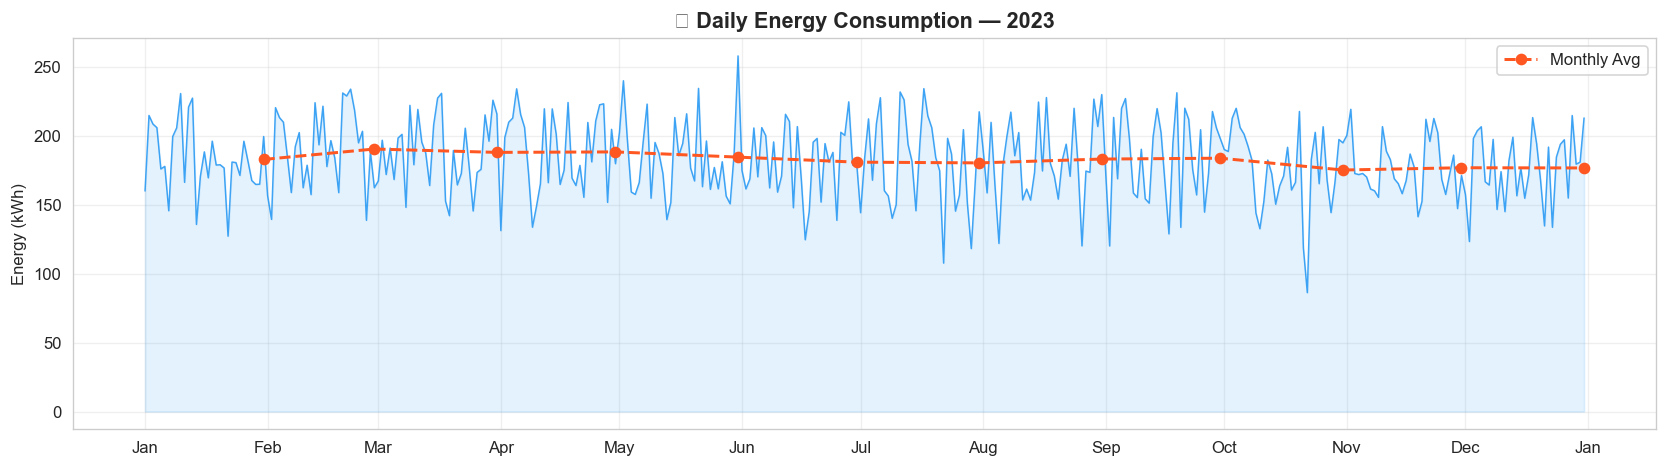

✅ Saved: plot1_energy_trend.png


In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['energy_kwh'], color='#2196F3', linewidth=0.9, alpha=0.85)
ax.fill_between(df.index, df['energy_kwh'], alpha=0.12, color='#2196F3')

monthly_avg = df['energy_kwh'].resample('ME').mean()
ax.plot(monthly_avg.index, monthly_avg.values, 'o--',
        color='#FF5722', linewidth=1.8, markersize=6, label='Monthly Avg')

ax.set_title('⚡ Daily Energy Consumption — 2023', fontsize=13, fontweight='bold')
ax.set_ylabel('Energy (kWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_energy_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot1_energy_trend.png")

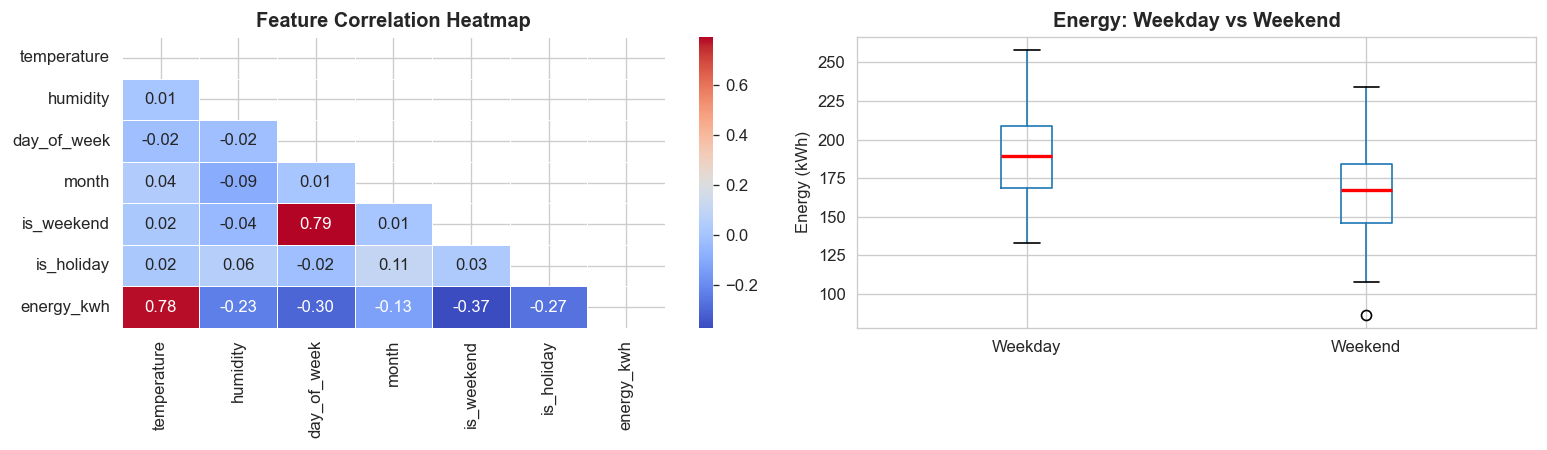

✅ Saved: plot2_eda.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

corr = df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap', fontweight='bold')

df['day_type'] = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})
df.boxplot(column='energy_kwh', by='day_type', ax=axes[1],
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Energy: Weekday vs Weekend', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Energy (kWh)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('plot2_eda.png', dpi=150, bbox_inches='tight')
plt.show()
df.drop(columns=['day_type'], inplace=True)
print("✅ Saved: plot2_eda.png")

In [6]:
FEATURES = ['temperature', 'humidity', 'day_of_week', 'month', 'is_weekend', 'is_holiday']
TARGET   = 'energy_kwh'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Split done | Train: {len(X_train)}  Test: {len(X_test)}")

✅ Split done | Train: 292  Test: 73


In [7]:
model = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


In [8]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("="*42)
print("     📈 MODEL EVALUATION RESULTS")
print("="*42)
print(f"  RMSE  : {rmse:.2f} kWh")
print(f"  MAE   : {mae:.2f} kWh")
print(f"  MAPE  : {mape:.2f}%")
print(f"  R²    : {r2:.4f}  ({r2*100:.1f}% accuracy)")
print("="*42)
print("  Grade:", "🟢 EXCELLENT" if r2 >= 0.90 else "🟡 GOOD" if r2 >= 0.75 else "🔴 NEEDS WORK")

     📈 MODEL EVALUATION RESULTS
  RMSE  : 9.71 kWh
  MAE   : 7.75 kWh
  MAPE  : 4.36%
  R²    : 0.8741  (87.4% accuracy)
  Grade: 🟡 GOOD


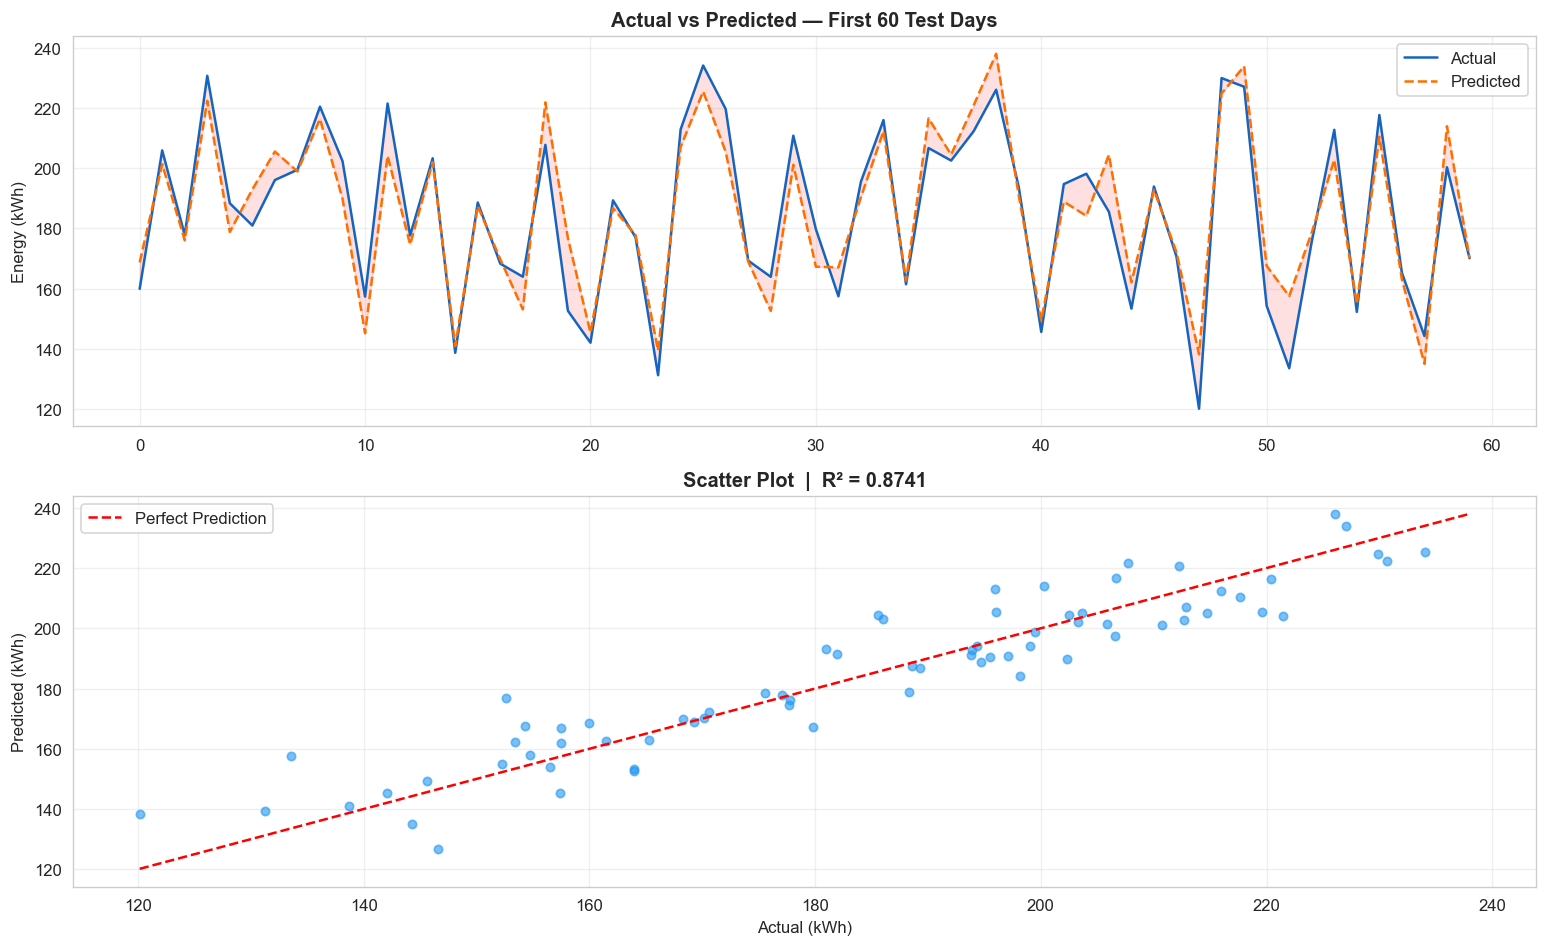

✅ Saved: plot3_actual_vs_predicted.png


In [9]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred},
                        index=y_test.index).sort_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(results['Actual'].values[:60], label='Actual', color='#1565C0', linewidth=1.5)
axes[0].plot(results['Predicted'].values[:60], label='Predicted', color='#FF6F00',
             linewidth=1.5, linestyle='--')
axes[0].fill_between(range(60), results['Actual'].values[:60],
                     results['Predicted'].values[:60], alpha=0.12, color='red')
axes[0].set_title('Actual vs Predicted — First 60 Test Days', fontweight='bold')
axes[0].set_ylabel('Energy (kWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(results['Actual'], results['Predicted'],
                alpha=0.6, color='#2196F3', s=25)
lims = [results.min().min(), results.max().max()]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_title(f'Scatter Plot  |  R² = {r2:.4f}', fontweight='bold')
axes[1].set_xlabel('Actual (kWh)')
axes[1].set_ylabel('Predicted (kWh)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot3_actual_vs_predicted.png")

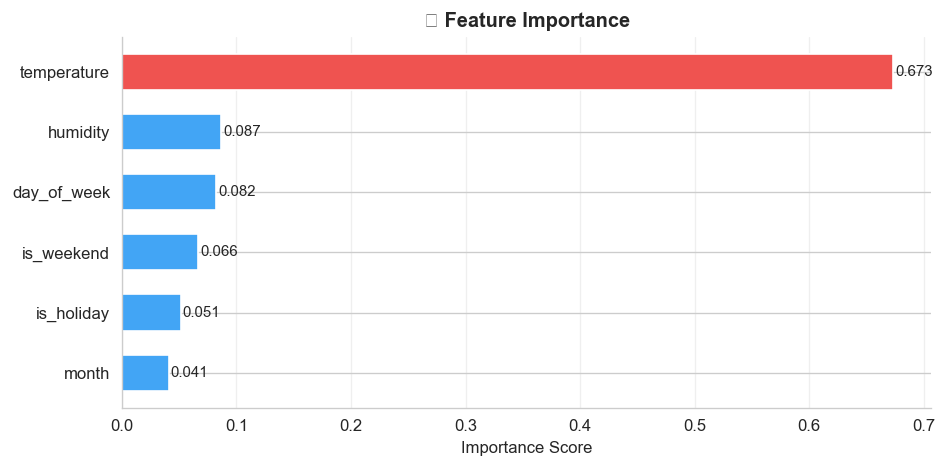

✅ Saved | Top feature: 'temperature'


In [10]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
colors = ['#EF5350' if x == importances.max() else '#42A5F5' for x in importances.values]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(importances.index, importances.values, color=colors, height=0.6)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('🔍 Feature Importance', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plot4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved | Top feature: '{importances.idxmax()}'")

In [11]:
future_dates = pd.date_range(start='2024-01-01', periods=7, freq='D')
future_input = pd.DataFrame({
    'temperature' : [22.5, 24.0, 28.3, 31.0, 35.5, 33.2, 27.8],
    'humidity'    : [65, 70, 60, 55, 48, 52, 68],
    'day_of_week' : [d.dayofweek for d in future_dates],
    'month'       : [d.month for d in future_dates],
    'is_weekend'  : [(d.dayofweek >= 5)*1 for d in future_dates],
    'is_holiday'  : [0, 0, 0, 0, 1, 0, 0]
})

forecast = model.predict(future_input)

print("="*52)
print("   ⚡ 7-DAY ENERGY FORECAST")
print("="*52)
for d, f, row in zip(future_dates, forecast, future_input.itertuples()):
    tag = " 🏖️ Holiday" if row.is_holiday else (" 📅 Weekend" if row.is_weekend else "")
    print(f"  {d.strftime('%a %d %b')} | {row.temperature}°C | {f:.1f} kWh{tag}")
print("="*52)
print(f"  Weekly Total : {forecast.sum():.1f} kWh")
print(f"  Daily Avg    : {forecast.mean():.1f} kWh")

   ⚡ 7-DAY ENERGY FORECAST
  Mon 01 Jan | 22.5°C | 166.2 kWh
  Tue 02 Jan | 24.0°C | 173.4 kWh
  Wed 03 Jan | 28.3°C | 184.4 kWh
  Thu 04 Jan | 31.0°C | 199.3 kWh
  Fri 05 Jan | 35.5°C | 202.9 kWh 🏖️ Holiday
  Sat 06 Jan | 33.2°C | 176.9 kWh 📅 Weekend
  Sun 07 Jan | 27.8°C | 166.3 kWh 📅 Weekend
  Weekly Total : 1269.3 kWh
  Daily Avg    : 181.3 kWh


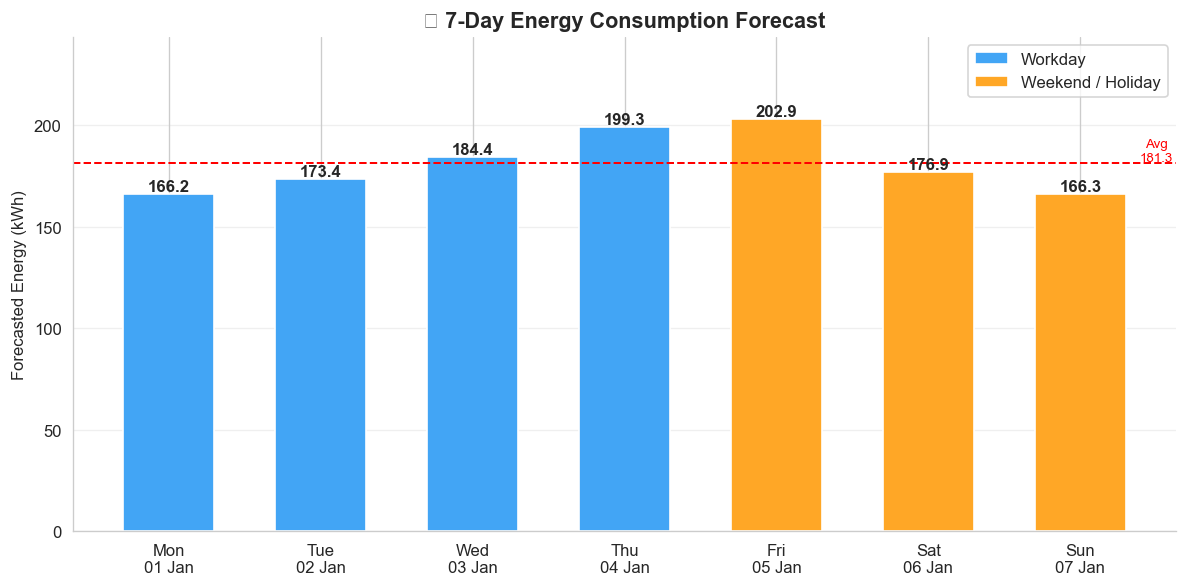

✅ Saved: plot5_forecast.png


In [12]:
from matplotlib.patches import Patch

day_labels = [f"{d.strftime('%a')}\n{d.strftime('%d %b')}" for d in future_dates]
bar_colors = ['#FFA726' if (future_input['is_weekend'].iloc[i] or future_input['is_holiday'].iloc[i])
              else '#42A5F5' for i in range(7)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(day_labels, forecast, color=bar_colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, forecast):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

avg = forecast.mean()
ax.axhline(avg, color='red', linestyle='--', linewidth=1.2)
ax.text(6.5, avg + 1, f'Avg\n{avg:.1f}', color='red', fontsize=8, ha='center')

legend_elements = [
    Patch(facecolor='#42A5F5', label='Workday'),
    Patch(facecolor='#FFA726', label='Weekend / Holiday')
]
ax.legend(handles=legend_elements)
ax.set_title('⚡ 7-Day Energy Consumption Forecast', fontsize=13, fontweight='bold')
ax.set_ylabel('Forecasted Energy (kWh)')
ax.set_ylim(0, max(forecast) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plot5_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot5_forecast.png")

In [13]:
print("="*50)
print("   ✅ PROJECT COMPLETE")
print("="*50)
print(f"   Algorithm : Random Forest ({model.n_estimators} trees)")
print(f"   Dataset   : 365 days | {len(FEATURES)} features")
print(f"   R² Score  : {r2:.4f} ({r2*100:.1f}% accuracy)")
print(f"   RMSE      : {rmse:.2f} kWh")
print(f"   MAE       : {mae:.2f} kWh")
print()
print("   Plots saved:")
for i, name in enumerate(['energy_trend','eda','actual_vs_predicted',
                           'feature_importance','forecast'], 1):
    print(f"   plot{i}_{name}.png")
print("="*50)
print("   🚀 Push to GitHub!")

   ✅ PROJECT COMPLETE
   Algorithm : Random Forest (150 trees)
   Dataset   : 365 days | 6 features
   R² Score  : 0.8741 (87.4% accuracy)
   RMSE      : 9.71 kWh
   MAE       : 7.75 kWh

   Plots saved:
   plot1_energy_trend.png
   plot2_eda.png
   plot3_actual_vs_predicted.png
   plot4_feature_importance.png
   plot5_forecast.png
   🚀 Push to GitHub!
